<a href="https://colab.research.google.com/github/saurabhsen848/Generative-AI_Assignment/blob/main/DCGAN_FashionMNIST_Assignment4_Gen_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 — Training a DCGAN on Fashion-MNIST

**Objective:** Understand how a Deep Convolutional Generative Adversarial Network (DCGAN) is trained, and how the generator and discriminator improve (or struggle) over time.

This notebook:
- Implements a DCGAN (transposed-conv Generator, conv Discriminator) in PyTorch
- Trains on Fashion-MNIST for 30 epochs
- Saves a 4x4 grid of generated images every 5 epochs
- Records Generator loss and Discriminator loss every step
- Plots both loss curves at the end
- Includes a template for your written analysis

> Run this top-to-bottom in Google Colab (enable GPU: Runtime > Change runtime type > T4 GPU) or locally with a CUDA GPU. On CPU it will be very slow.

In [1]:
# 1. Imports
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# 2. Hyperparameters
BATCH_SIZE   = 128
IMAGE_SIZE   = 64      # we upsample Fashion-MNIST's 28x28 to 64x64, standard for DCGAN architecture
NZ           = 100     # size of the latent (noise) vector
NGF          = 64      # base number of generator feature maps
NDF          = 64      # base number of discriminator feature maps
NUM_EPOCHS   = 30
LR           = 0.0002
BETA1        = 0.5     # Adam beta1, standard DCGAN value
OUT_DIR      = "outputs"
GRID_DIR     = os.path.join(OUT_DIR, "grids")
os.makedirs(GRID_DIR, exist_ok=True)

torch.manual_seed(42)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.83MB/s]

Dataset size: 60000 images, 468 batches per epoch


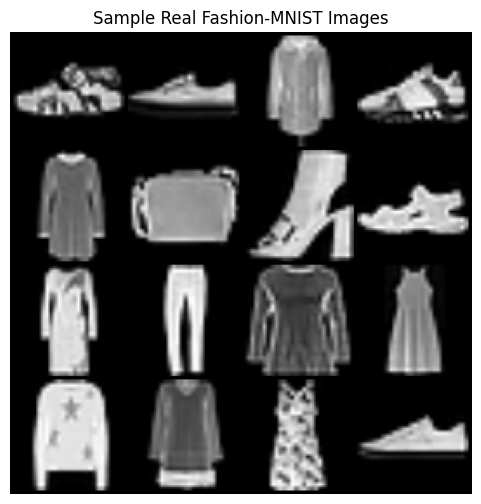

In [3]:
# 3. Data: Fashion-MNIST
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1] to match generator's Tanh output
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)} images, {len(dataloader)} batches per epoch")

# sanity check: show a batch of real images
real_batch = next(iter(dataloader))
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Sample Real Fashion-MNIST Images")
plt.imshow(np.transpose(
    vutils.make_grid(real_batch[0][:16], padding=2, normalize=True, nrow=4).cpu(), (1, 2, 0)
))
plt.show()

## 4. Model Definitions

- **Generator**: takes a 100-dim noise vector and upsamples it through 5 transposed-convolution layers into a 1x64x64 image.
- **Discriminator**: mirrors the generator with strided convolutions, reducing a 1x64x64 image down to a single real/fake probability.

Weights are initialized from N(0, 0.02) as in the original DCGAN paper — this makes training noticeably more stable.

In [4]:
# 5. Weight initialization (DCGAN paper recommendation)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
# 6. Generator (transposed convolutions)
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=1):
        super().__init__()
        self.main = nn.Sequential(
            # input: nz x 1 x 1
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state: (ngf*8) x 4 x 4

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state: (ngf*4) x 8 x 8

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state: (ngf*2) x 16 x 16

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state: ngf x 32 x 32

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # output: nc x 64 x 64
        )

    def forward(self, x):
        return self.main(x)

In [6]:
# 7. Discriminator (strided convolutions)
class Discriminator(nn.Module):
    def __init__(self, nc=1, ndf=NDF):
        super().__init__()
        self.main = nn.Sequential(
            # input: nc x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state: ndf x 32 x 32

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf*2) x 16 x 16

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf*4) x 8 x 8

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf*8) x 4 x 4

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # output: 1 x 1 x 1 -> probability real/fake
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

In [7]:
# 8. Instantiate models, loss, optimizers
netG = Generator().to(device)
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

print(netG)
print(netD)

criterion = nn.BCELoss()

# fixed noise so we can watch the SAME latent vectors evolve across epochs
fixed_noise = torch.randn(16, NZ, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


## 9. Training Loop

Standard DCGAN alternating-update procedure, each batch:

1. **Update D**: maximize `log(D(real)) + log(1 - D(G(z)))` — train on an all-real batch, then an all-fake batch.
2. **Update G**: maximize `log(D(G(z)))` (the non-saturating trick) — i.e. train G to fool D.

We log `Loss_D` and `Loss_G` every batch, and save a 4x4 grid from the fixed noise vector every 5 epochs so we can see the *same* generated samples improve over training.

In [ ]:
# 10. Training
G_losses = []
D_losses = []
epoch_avg_G = []
epoch_avg_D = []
img_list = []       # stores grids for later inline display
saved_epochs = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    running_G, running_D, nb = 0.0, 0.0, 0

    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # -----------------------------
        # (1) Update Discriminator
        # -----------------------------
        netD.zero_grad()

        # train on real batch
        label = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        output = netD(real_images)
        lossD_real = criterion(output, label)
        lossD_real.backward()

        # train on fake batch
        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(FAKE_LABEL)
        output = netD(fake_images.detach())
        lossD_fake = criterion(output, label)
        lossD_fake.backward()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # -----------------------------
        # (2) Update Generator
        # -----------------------------
        netG.zero_grad()
        label.fill_(REAL_LABEL)  # generator wants D to think fakes are real
        output = netD(fake_images)
        lossG = criterion(output, label)
        lossG.backward()
        optimizerG.step()

        # -----------------------------
        # Logging
        # -----------------------------
        G_losses.append(lossG.item())
        D_losses.append(lossD.item())
        running_G += lossG.item()
        running_D += lossD.item()
        nb += 1

        if i % 100 == 0:
            print(f"[Epoch {epoch}/{NUM_EPOCHS}][Batch {i}/{len(dataloader)}] "
                  f"Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}")

    epoch_avg_G.append(running_G / nb)
    epoch_avg_D.append(running_D / nb)
    print(f"== Epoch {epoch} done | avg Loss_D: {epoch_avg_D[-1]:.4f} | "
          f"avg Loss_G: {epoch_avg_G[-1]:.4f} | elapsed: {time.time()-start_time:.0f}s ==")

    # Save a 4x4 grid every 5 epochs (and always on the last epoch)
    if epoch % 5 == 0 or epoch == NUM_EPOCHS:
        netG.eval()
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
        netG.train()

        grid = vutils.make_grid(fake, nrow=4, padding=2, normalize=True)
        img_list.append(grid)
        saved_epochs.append(epoch)

        fig = plt.figure(figsize=(4, 4))
        plt.axis("off")
        plt.title(f"Epoch {epoch}")
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        fig.savefig(os.path.join(GRID_DIR, f"epoch_{epoch:03d}.png"), bbox_inches="tight")
        plt.show()

print("Training finished in", round(time.time() - start_time, 1), "seconds")

[Epoch 1/30][Batch 0/468] Loss_D: 2.0518  Loss_G: 5.3575


## 11. Loss Curves

In [ ]:
# Per-batch loss curve (noisy but shows full detail)
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training (per batch)")
plt.plot(G_losses, label="G", alpha=0.8)
plt.plot(D_losses, label="D", alpha=0.8)
plt.xlabel("Iteration (batch)")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(OUT_DIR, "loss_per_batch.png"), bbox_inches="tight")
plt.show()

# Per-epoch average loss curve (cleaner trend line)
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training (per-epoch average)")
plt.plot(range(1, NUM_EPOCHS + 1), epoch_avg_G, marker="o", label="G (avg)")
plt.plot(range(1, NUM_EPOCHS + 1), epoch_avg_D, marker="o", label="D (avg)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.savefig(os.path.join(OUT_DIR, "loss_per_epoch.png"), bbox_inches="tight")
plt.show()

## 12. Generated Image Grids Across Epochs\n\nSide-by-side comparison of the same 16 fixed noise vectors, every 5 epochs.

In [ ]:
n = len(img_list)
cols = min(n, 4)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, grid, ep in zip(axes, img_list, saved_epochs):
    ax.imshow(np.transpose(grid, (1, 2, 0)))
    ax.set_title(f"Epoch {ep}")
    ax.axis("off")

for ax in axes[len(img_list):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grid_comparison_all_epochs.png"), bbox_inches="tight")
plt.show()

In [ ]:
# Save final model weights (optional, useful for reuse / grading)
torch.save(netG.state_dict(), os.path.join(OUT_DIR, "generator.pth"))
torch.save(netD.state_dict(), os.path.join(OUT_DIR, "discriminator.pth"))
print("Saved model weights to", OUT_DIR)